In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False) 

X, y = mnist.data, mnist.target
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [2]:
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt
import numpy as np
sgd_clf = SGDClassifier(random_state=42, n_jobs=1)

In [3]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)

In [6]:
incorrect_pred_mask = y_train_pred != y_train
X_incorrect_pred = X_train[incorrect_pred_mask]
y_incorrect_pred = y_train[incorrect_pred_mask]

X_train_with_dup = np.vstack([X_train, X_incorrect_pred])
y_train_with_dup = np.concatenate([y_train, y_incorrect_pred])

shuffle_inxs = np.random.permutation(len(X_train_with_dup))

X_train_with_dup = X_train_with_dup[shuffle_inxs]
y_train_with_dup = y_train_with_dup[shuffle_inxs]

In [7]:
y_train_pred_with_dup = cross_val_predict(sgd_clf, X_train_with_dup, y_train_with_dup, cv=3)

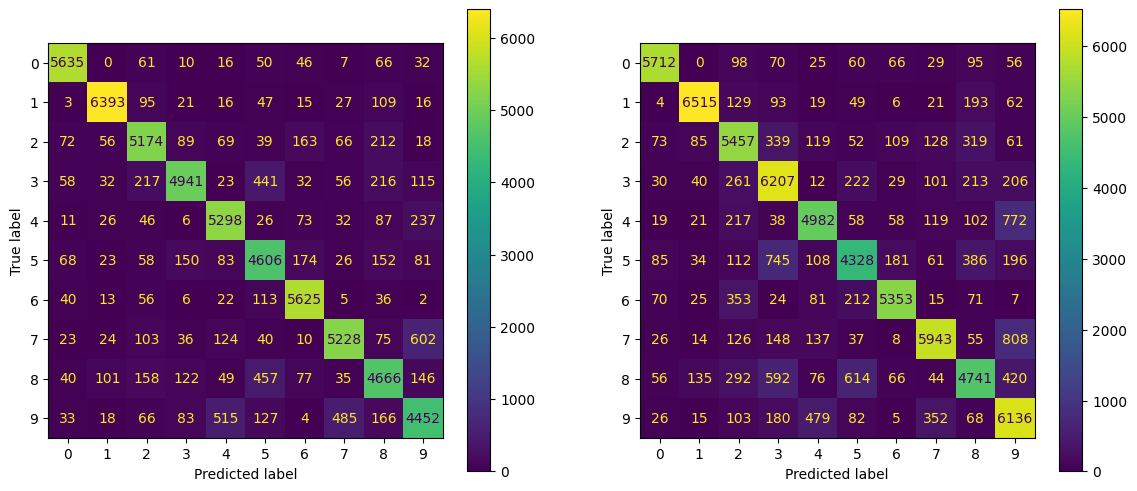

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_train_with_dup, y_train_pred_with_dup, ax=ax[1])
plt.show()